In [1]:
# Dependencies for this project are listed in requirements.txt
# Install with: pip install -r requirements.txt
print("Environment ready.")

Environment ready.


In [2]:
# ==========================================
# REQUIRED LIBRARIES IMPORT
# ==========================================

# Pandas: Main tool for data manipulation and analysis of tabular data
import pandas as pd

# NumPy: Numerical operations and array handling
import numpy as np

# Matplotlib / Seaborn: Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing, model training and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)

# Display configuration
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")

print("Libraries loaded.")

Libraries loaded.


## STEP 1: EXTRACT

In [3]:
# ==========================================
# 1.1 LOAD DATASET
# ==========================================

df = pd.read_csv("ai4i2020.csv")

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset loaded: 10,000 rows x 14 columns

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## STEP 2: EXPLORE & VALIDATE

In [4]:
# ==========================================
# 2.1 DATA TYPES, MISSING VALUES & DUPLICATES
# ==========================================

print("Data types:")
print(df.dtypes)
print(f"\nMissing values per column:\n{df.isnull().sum().sum()} total missing cells")
print(f"Duplicated rows: {df.duplicated().sum()}")

Data types:
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Missing values per column:
0 total missing cells
Duplicated rows: 0


In [5]:
# ==========================================
# 2.2 DESCRIPTIVE STATISTICS
# ==========================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [6]:
# ==========================================
# 2.3 TARGET VARIABLE: MACHINE FAILURE
# ==========================================

failure_counts = df["Machine failure"].value_counts()
failure_rate = df["Machine failure"].mean() * 100

print("Machine failure distribution:")
print(failure_counts)
print(f"\nFailure rate: {failure_rate:.2f}%")
print(f"Class imbalance ratio: {failure_counts[0] / failure_counts[1]:.1f} : 1 (healthy : failed)")

Machine failure distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%
Class imbalance ratio: 28.5 : 1 (healthy : failed)


In [7]:
# ==========================================
# 2.4 FAILURE MODE BREAKDOWN
# ==========================================

failure_modes = ["TWF", "HDF", "PWF", "OSF", "RNF"]
mode_labels = {
    "TWF": "Tool Wear Failure",
    "HDF": "Heat Dissipation Failure",
    "PWF": "Power Failure",
    "OSF": "Overstrain Failure",
    "RNF": "Random Failure",
}

print(f"{'Mode':<6}{'Description':<28}{'Count':>8}{'% of failures':>16}")
print("-" * 58)
total_failures = df["Machine failure"].sum()
for m in failure_modes:
    count = df[m].sum()
    pct = count / total_failures * 100
    print(f"{m:<6}{mode_labels[m]:<28}{count:>8}{pct:>15.1f}%")

# Consistency check: does the sum of individual failure-mode flags
# agree with the overall "Machine failure" flag?
df["_modes_sum"] = df[failure_modes].sum(axis=1)
df["_any_mode"] = (df["_modes_sum"] > 0).astype(int)
mismatch = (df["_any_mode"] != df["Machine failure"]).sum()
print(f"\nRows where the Machine failure flag disagrees with the individual mode flags: {mismatch} ({mismatch/len(df)*100:.2f}%)")
df.drop(columns=["_modes_sum", "_any_mode"], inplace=True)

Mode  Description                    Count   % of failures
----------------------------------------------------------
TWF   Tool Wear Failure                 46           13.6%
HDF   Heat Dissipation Failure         115           33.9%
PWF   Power Failure                     95           28.0%
OSF   Overstrain Failure                98           28.9%
RNF   Random Failure                    19            5.6%

Rows where the Machine failure flag disagrees with the individual mode flags: 27 (0.27%)


In [8]:
# ==========================================
# 2.5 PRODUCT TYPE DISTRIBUTION
# ==========================================

type_summary = df.groupby("Type")["Machine failure"].agg(units="count", failures="sum", failure_rate="mean")
type_summary["failure_rate"] = (type_summary["failure_rate"] * 100).round(2)
type_summary.sort_values("failure_rate", ascending=False)

,units,failures,failure_rate
Type,,,
L,6000,235,3.92
M,2997,83,2.77
H,1003,21,2.09


## STEP 3: FEATURE ENGINEERING

In [9]:
# ==========================================
# 3.1 DERIVED PROCESS VARIABLES
# ==========================================

# Temperature differential: how much the process temperature exceeds
# the surrounding air temperature. A small differential limits the
# machine's ability to dissipate heat (relevant to HDF failures).
df["Temp diff [K]"] = df["Process temperature [K]"] - df["Air temperature [K]"]

# Mechanical power delivered by the tool: torque x angular velocity.
# Angular velocity [rad/s] = rotational speed [rpm] x (2*pi / 60)
df["Power [W]"] = df["Torque [Nm]"] * df["Rotational speed [rpm]"] * (2 * np.pi / 60)

df[["Temp diff [K]", "Power [W]"]].describe()

,Temp diff [K],Power [W]
count,10000.000000,10000.000000
mean,10.000630,6279.744953
std,1.001094,1067.418295
min,7.600000,1148.440610
25%,9.300000,5561.184484
50%,9.800000,6271.027344
75%,11.000000,7003.002724
max,12.100000,10469.923005


In [10]:
# ==========================================
# 3.2 CORRELATION WITH MACHINE FAILURE
# ==========================================

numeric_features = [
    "Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]",
    "Torque [Nm]", "Tool wear [min]", "Temp diff [K]", "Power [W]"
]

corr_with_target = (
    df[numeric_features + ["Machine failure"]]
    .corr()["Machine failure"]
    .drop("Machine failure")
    .sort_values(key=abs, ascending=False)
)
print("Correlation with Machine failure:")
print(corr_with_target.round(3))

print("\nMean values - healthy vs. failed machines:")
df.groupby("Machine failure")[numeric_features].mean().T.round(2)

Correlation with Machine failure:
Torque [Nm]                0.191
Power [W]                  0.176
Temp diff [K]             -0.112
Tool wear [min]            0.105
Air temperature [K]        0.083
Rotational speed [rpm]    -0.044
Process temperature [K]    0.036
Name: Machine failure, dtype: float64

Mean values - healthy vs. failed machines:


Machine failure,0,1
Air temperature [K],299.97,300.89
Process temperature [K],310.00,310.29
Rotational speed [rpm],1540.26,1496.49
Torque [Nm],39.63,50.17
Tool wear [min],106.69,143.78
Temp diff [K],10.02,9.40
Power [W],6244.55,7282.82


## STEP 4: DATA VISUALIZATION

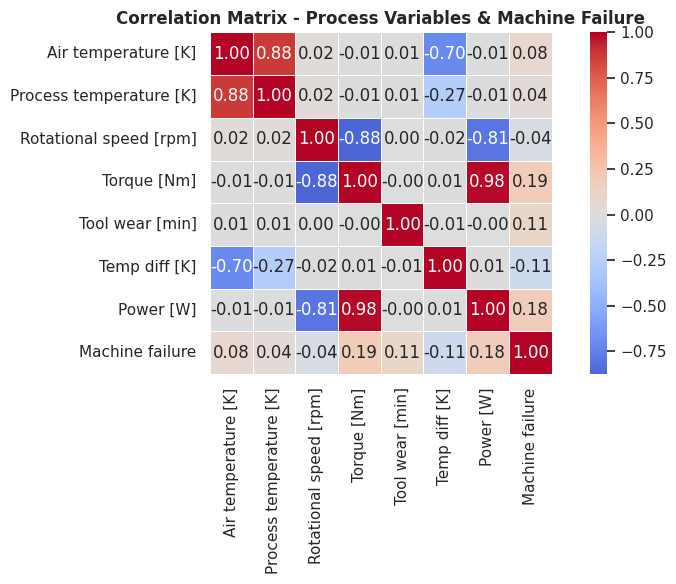

In [11]:
# ==========================================
# 4.1 CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(9, 6))
corr_matrix = df[numeric_features + ["Machine failure"]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True)
plt.title("Correlation Matrix - Process Variables & Machine Failure", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()

/tmp/ipykernel_185/939385170.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(["Healthy", "Failed"])
/tmp/ipykernel_185/939385170.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(["Healthy", "Failed"])
/tmp/ipykernel_185/939385170.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(["Healthy", "Failed"])


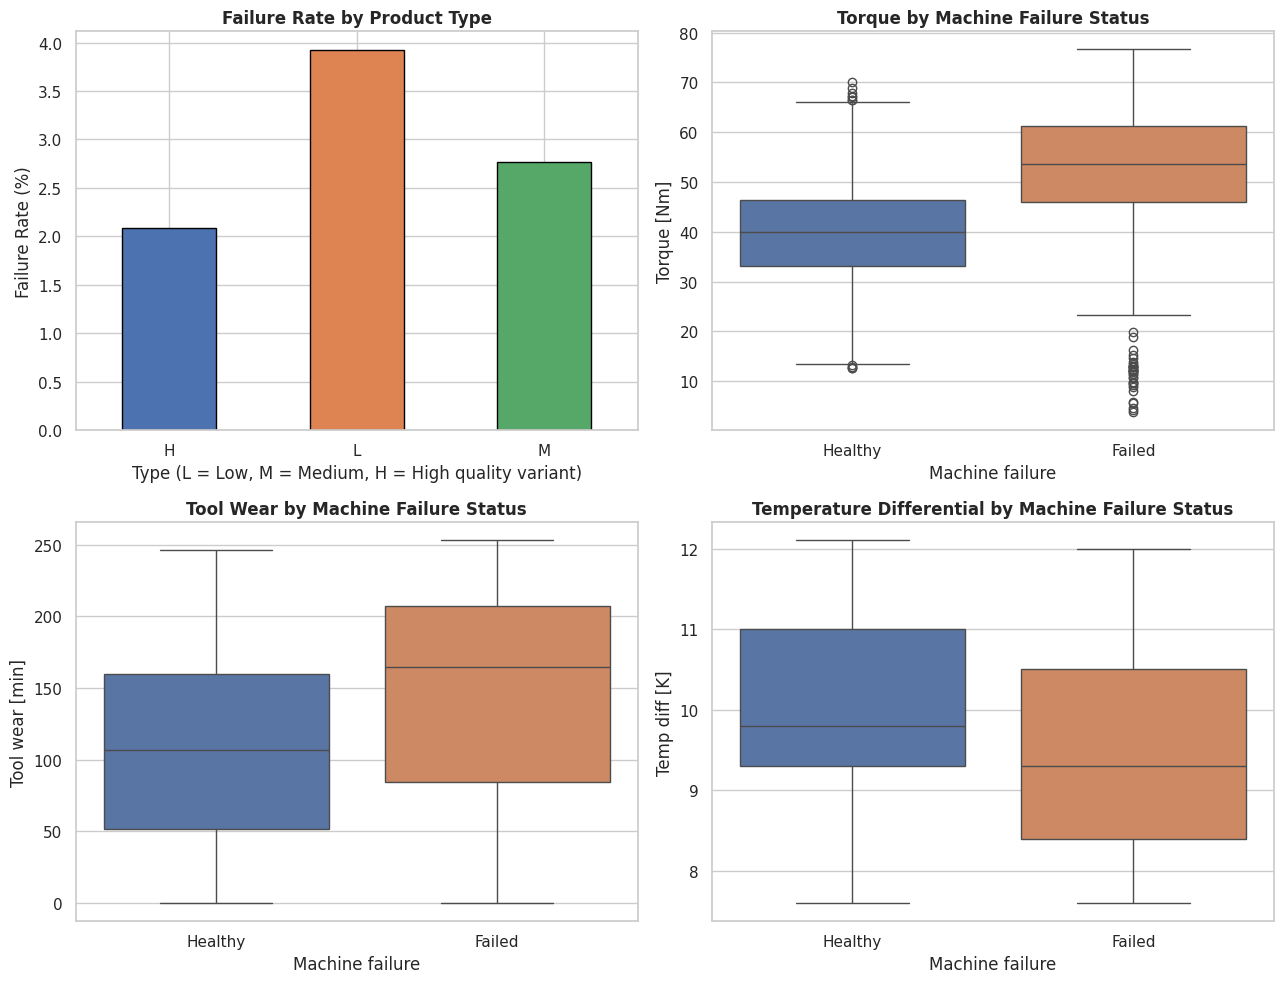

In [12]:
# ==========================================
# 4.2 FAILURE RATE BY PRODUCT TYPE & KEY VARIABLE DISTRIBUTIONS
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Failure rate by product quality type
type_summary["failure_rate"].sort_index().plot(
    kind="bar", ax=axes[0, 0], color=["#4C72B0", "#DD8452", "#55A868"], edgecolor="black"
)
axes[0, 0].set_title("Failure Rate by Product Type", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Type (L = Low, M = Medium, H = High quality variant)")
axes[0, 0].set_ylabel("Failure Rate (%)")
axes[0, 0].tick_params(axis="x", rotation=0)

# 2. Torque distribution by failure status
sns.boxplot(data=df, x="Machine failure", y="Torque [Nm]", ax=axes[0, 1], hue="Machine failure", legend=False)
axes[0, 1].set_title("Torque by Machine Failure Status", fontsize=12, fontweight="bold")
axes[0, 1].set_xticklabels(["Healthy", "Failed"])

# 3. Tool wear distribution by failure status
sns.boxplot(data=df, x="Machine failure", y="Tool wear [min]", ax=axes[1, 0], hue="Machine failure", legend=False)
axes[1, 0].set_title("Tool Wear by Machine Failure Status", fontsize=12, fontweight="bold")
axes[1, 0].set_xticklabels(["Healthy", "Failed"])

# 4. Temperature differential by failure status
sns.boxplot(data=df, x="Machine failure", y="Temp diff [K]", ax=axes[1, 1], hue="Machine failure", legend=False)
axes[1, 1].set_title("Temperature Differential by Machine Failure Status", fontsize=12, fontweight="bold")
axes[1, 1].set_xticklabels(["Healthy", "Failed"])

plt.tight_layout()
plt.savefig("failure_analysis_overview.png", dpi=120)
plt.show()

## STEP 5: PREDICTIVE MODELING - FAILURE CLASSIFICATION

In [13]:
# ==========================================
# 5.1 TRAIN / TEST SPLIT
# ==========================================

# Product ID and UDI are unique identifiers (no predictive value).
# TWF/HDF/PWF/OSF/RNF are components of the Machine failure label itself
# (their sum determines it) - including them would leak the target,
# so they are excluded from the feature set.
feature_cols = numeric_features + ["Type"]
X = df[feature_cols]
y = df["Machine failure"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Train set: {X_train.shape[0]:,} rows | Failure rate: {y_train.mean()*100:.2f}%")
print(f"Test set:  {X_test.shape[0]:,} rows | Failure rate: {y_test.mean()*100:.2f}%")

Train set: 8,000 rows | Failure rate: 3.39%
Test set:  2,000 rows | Failure rate: 3.40%


In [14]:
# ==========================================
# 5.2 PREPROCESSING PIPELINE
# ==========================================

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first"), ["Type"]),
])

print("Preprocessing pipeline ready: StandardScaler (numeric) + OneHotEncoder (Type).")

Preprocessing pipeline ready: StandardScaler (numeric) + OneHotEncoder (Type).


In [15]:
# ==========================================
# 5.3 MODEL TRAINING - LOGISTIC REGRESSION (BASELINE)
# ==========================================

# class_weight="balanced" compensates for the 3.4% failure rate by
# re-weighting the minority class during training.
log_reg = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION - Test set performance")
print("=" * 55)
print(classification_report(y_test, y_pred_lr, digits=3, target_names=["Healthy", "Failed"]))
print("Confusion matrix [rows=actual, cols=predicted]:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba_lr):.3f}   PR-AUC: {average_precision_score(y_test, y_proba_lr):.3f}")

LOGISTIC REGRESSION - Test set performance
              precision    recall  f1-score   support

     Healthy      0.995     0.859     0.922      1932
      Failed      0.178     0.868     0.295        68

    accuracy                          0.859      2000
   macro avg      0.586     0.863     0.608      2000
weighted avg      0.967     0.859     0.900      2000

Confusion matrix [rows=actual, cols=predicted]:
[[1659  273]
 [   9   59]]

ROC-AUC: 0.934   PR-AUC: 0.466


In [16]:
# ==========================================
# 5.4 MODEL TRAINING - RANDOM FOREST
# ==========================================

rand_forest = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    )),
])
rand_forest.fit(X_train, y_train)

y_pred_rf = rand_forest.predict(X_test)
y_proba_rf = rand_forest.predict_proba(X_test)[:, 1]

print("RANDOM FOREST - Test set performance")
print("=" * 55)
print(classification_report(y_test, y_pred_rf, digits=3, target_names=["Healthy", "Failed"]))
print("Confusion matrix [rows=actual, cols=predicted]:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba_rf):.3f}   PR-AUC: {average_precision_score(y_test, y_proba_rf):.3f}")

RANDOM FOREST - Test set performance
              precision    recall  f1-score   support

     Healthy      0.991     0.998     0.995      1932
      Failed      0.943     0.735     0.826        68

    accuracy                          0.990      2000
   macro avg      0.967     0.867     0.911      2000
weighted avg      0.989     0.990     0.989      2000

Confusion matrix [rows=actual, cols=predicted]:
[[1929    3]
 [  18   50]]

ROC-AUC: 0.978   PR-AUC: 0.863


In [17]:
# ==========================================
# 5.5 MODEL COMPARISON
# ==========================================

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_lr), roc_auc_score(y_test, y_proba_rf)],
    "PR-AUC": [average_precision_score(y_test, y_proba_lr), average_precision_score(y_test, y_proba_rf)],
    "Recall (Failed)": [
        confusion_matrix(y_test, y_pred_lr)[1, 1] / y_test.sum(),
        confusion_matrix(y_test, y_pred_rf)[1, 1] / y_test.sum(),
    ],
    "Precision (Failed)": [
        confusion_matrix(y_test, y_pred_lr)[1, 1] / y_pred_lr.sum(),
        confusion_matrix(y_test, y_pred_rf)[1, 1] / y_pred_rf.sum(),
    ],
})
comparison.round(3)

,Model,ROC-AUC,PR-AUC,Recall (Failed),Precision (Failed)
0,Logistic Regression,0.934,0.466,0.868,0.178
1,Random Forest,0.978,0.863,0.735,0.943


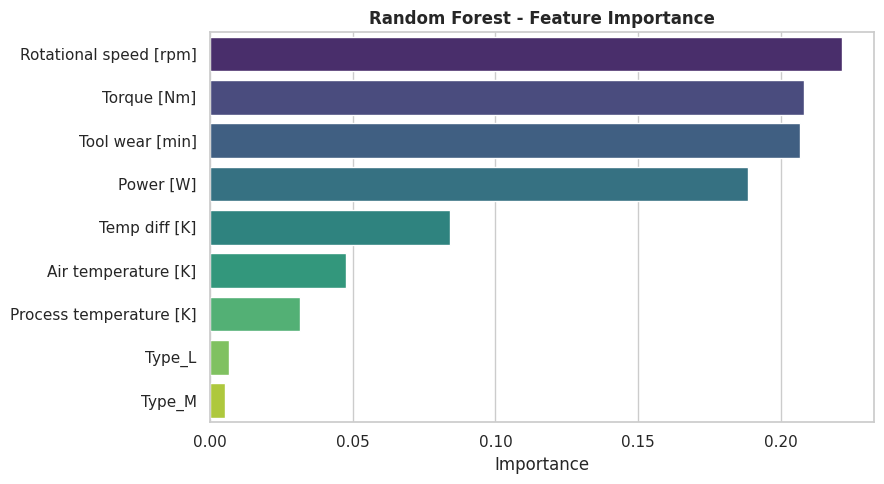

,feature,importance
0,Rotational speed [rpm],0.221509
1,Torque [Nm],0.208048
2,Tool wear [min],0.206503
3,Power [W],0.188432
4,Temp diff [K],0.084260
5,Air temperature [K],0.047854
6,Process temperature [K],0.031562
7,Type_L,0.006627
8,Type_M,0.005205


In [18]:
# ==========================================
# 5.6 FEATURE IMPORTANCE (RANDOM FOREST)
# ==========================================

feature_names = numeric_features + list(
    rand_forest.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(["Type"])
)
importances = rand_forest.named_steps["clf"].feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_names, "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x="importance", y="feature", hue="feature", palette="viridis", legend=False)
plt.title("Random Forest - Feature Importance", fontsize=12, fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()

importance_df

## STEP 6: EXPORT & SUMMARY

In [19]:
# ==========================================
# 6.1 EXPORT RESULTS
# ==========================================

# Random Forest predictions on the held-out test set
test_results = X_test.copy()
test_results["actual_failure"] = y_test.values
test_results["predicted_failure"] = y_pred_rf
test_results["failure_probability"] = y_proba_rf.round(4)
test_results.to_csv("test_set_predictions.csv", index=False)

importance_df.to_csv("feature_importance.csv", index=False)

print("Exported files:")
print(f"  test_set_predictions.csv  ({len(test_results):,} rows)")
print(f"  feature_importance.csv    ({len(importance_df)} rows)")

Exported files:
  test_set_predictions.csv  (2,000 rows)
  feature_importance.csv    (9 rows)


In [20]:
# ==========================================
# 6.2 PROJECT SUMMARY
# ==========================================

failure_col = "Machine failure"
top_feature = importance_df.iloc[0]["feature"]

print("=" * 60)
print("PREDICTIVE MAINTENANCE - PROJECT SUMMARY")
print("=" * 60)
print()
print("DATASET")
print(f"  Source          : AI4I 2020 Predictive Maintenance Dataset (UCI)")
print(f"  Records         : {len(df):,} machine operating instances")
print(f"  Failure rate    : {df[failure_col].mean()*100:.2f}% (severe class imbalance)")
print()
print("MODELING")
print(f"  Models compared : Logistic Regression (baseline), Random Forest")
print(f"  Best model      : Random Forest")
print(f"  ROC-AUC         : {roc_auc_score(y_test, y_proba_rf):.3f}")
print(f"  PR-AUC          : {average_precision_score(y_test, y_proba_rf):.3f}")
print(f"  Top driver      : {top_feature}")
print()
print("OUTPUT")
print(f"  test_set_predictions.csv, feature_importance.csv")

PREDICTIVE MAINTENANCE - PROJECT SUMMARY

DATASET
  Source          : AI4I 2020 Predictive Maintenance Dataset (UCI)
  Records         : 10,000 machine operating instances
  Failure rate    : 3.39% (severe class imbalance)

MODELING
  Models compared : Logistic Regression (baseline), Random Forest
  Best model      : Random Forest
  ROC-AUC         : 0.978
  PR-AUC          : 0.863
  Top driver      : Rotational speed [rpm]

OUTPUT
  test_set_predictions.csv, feature_importance.csv
